<a href="https://colab.research.google.com/github/Comfy05/Football_analytics_portfolio/blob/main/player_heatmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mplsoccer
!pip install statsbombpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.3/108.3 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.2 MB/s eta 0:00:00


In [15]:
from pandas.core.arrays import period
import pandas as pd
from statsbombpy import sb
from mplsoccer import Pitch, VerticalPitch
from matplotlib.pyplot import scatter
import matplotlib.pyplot as plt
import scipy as sc
from scipy.ndimage import gaussian_filter

In [13]:
competitions = sb.competitions()
event = sb.events(match_id=22912)

player = event['player'] == "Mohamed Salah"
player_map = event[player]
player_map = player_map.join(pd.DataFrame(player_map.pop('location').tolist(), index = player_map.index, columns=["x", 'y']))
player_map

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,...,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,x,y
66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Liverpool,24,00:06:01.597,Pass,True,105.1,56.6
217,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Liverpool,24,00:20:28.007,Pass,NaN,91.4,66.9
286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Liverpool,24,00:29:01.363,Pass,NaN,82.8,42.3
318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Liverpool,24,00:31:01.188,Pass,NaN,84.5,74.9
386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Liverpool,24,00:36:55.929,Pass,NaN,110.1,78.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3054,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Liverpool,24,00:45:50.191,Miscontrol,NaN,75.4,58.3
3057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Liverpool,24,00:18:39.714,Miscontrol,NaN,98.9,76.0
3061,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Liverpool,24,00:40:17.467,Miscontrol,NaN,92.5,25.3
3076,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Liverpool,24,00:08:11.118,Dispossessed,True,94.5,49.0


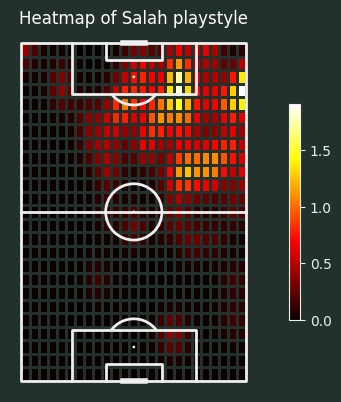

In [19]:
pitch = VerticalPitch(pitch_type='statsbomb', line_zorder=2,
              pitch_color='#22312b', line_color='#efefef')
# draw
fig, ax = pitch.draw(figsize=(6.6, 4.125))
fig.set_facecolor('#22312b')
bin_statistic = pitch.bin_statistic(player_map.x, player_map.y, statistic='count', bins=(25, 25))
bin_statistic['statistic'] = gaussian_filter(bin_statistic['statistic'], 1)
pcm = pitch.heatmap(bin_statistic, ax=ax, cmap='hot', edgecolors='#22312b')
# Add the colorbar and format off-white
cbar = fig.colorbar(pcm, ax=ax, shrink=0.6)
cbar.outline.set_edgecolor('#efefef')
cbar.ax.yaxis.set_tick_params(color='#efefef')
ticks = plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='#efefef')
ax.set_title('Heatmap of Salah playstyle', color='white')
plt.savefig('Heatmap_of_Salah_playstyle_CL_Final2019.pdf')